# CH8 demod noise — MOD10_Gain4_NoNTC

Analyse channel 8 from `MOD10_Gain4_NoNTC.csv`. CH8 carries the FPGA half-cycle demod output
(CH1 lock-in at 10 Hz). The CSV has a handful of corrupted lines from USB logging; the loader
skips those automatically.

In [1]:
from pathlib import Path

MEASUREMENT_PATH = Path("../logged_files/Better-wiring/NoNTC/MOD10_Gain4_NoNTC.csv")
CHANNEL = "ch8"
REFERENCE_VOLTS = 2.5

In [2]:
import io
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT / "reference" / "speckit-1.0.2"))

from speckit import compute_single_bin, compute_spectrum

RP_ADC_CLOCK_HZ = 125_000_000.0
ADS1278_CLOCKS_PER_SAMPLE = 512.0
CODE_SCALE = 1 << 23

In [3]:
def read_rp_csv(path: Path, usecols: list[str]) -> tuple[pd.DataFrame, int]:
    """Load rp_ads1278 CSV, skipping lines that are not valid UTF-8."""
    chunks: list[pd.DataFrame] = []
    skipped = 0
    buf: list[str] = []
    chunk_rows = 200_000

    with open(path, "rb") as f:
        header = f.readline().decode("utf-8")
        for line in f:
            try:
                buf.append(line.decode("utf-8"))
            except UnicodeDecodeError:
                skipped += 1
                continue
            if len(buf) >= chunk_rows:
                chunks.append(pd.read_csv(io.StringIO(header + "".join(buf)), usecols=usecols))
                buf = []
        if buf:
            chunks.append(pd.read_csv(io.StringIO(header + "".join(buf)), usecols=usecols))

    return pd.concat(chunks, ignore_index=True), skipped


def load_ch8_demod(path: Path) -> tuple[np.ndarray, float, int, int, int]:
    usecols = ["extclk_div", "mod_div", "ch8"]
    df, skipped = read_rp_csv(path, usecols)

    mod_div = int(df["mod_div"].iloc[0])
    fs = RP_ADC_CLOCK_HZ / (2.0 * mod_div)

    codes = df["ch8"].to_numpy(dtype=float)
    finite = np.isfinite(codes)
    dropped_nonfinite = int(np.count_nonzero(~finite))
    codes = codes[finite]

    # CH8 updates once per mod half-cycle and is held between updates.
    idx = np.concatenate([[0], np.flatnonzero(np.diff(codes) != 0) + 1])
    codes = codes[idx]

    volts = codes * (REFERENCE_VOLTS / CODE_SCALE)
    volts = volts - volts.mean()

    return volts, fs, skipped, len(df), dropped_nonfinite


volts, fs, skipped_lines, raw_rows, dropped_nonfinite = load_ch8_demod(MEASUREMENT_PATH)
duration_s = len(volts) / fs

print(f"File: {MEASUREMENT_PATH.name}")
print(f"Skipped corrupted lines: {skipped_lines:,}")
print(f"Dropped non-finite CH8 rows: {dropped_nonfinite:,}")
print(f"Raw ADC rows kept: {raw_rows:,}")
print(f"Decimated CH8 samples: {len(volts):,}")
print(f"Sample rate (mod rate): {fs:.2f} Hz")
print(f"Duration: {duration_s / 3600:.2f} h ({duration_s:.0f} s)")
print(f"RMS: {volts.std():.6e} V")

File: MOD10_Gain4_NoNTC.csv
Skipped corrupted lines: 474
Dropped non-finite CH8 rows: 2
Raw ADC rows kept: 22,516,195
Decimated CH8 samples: 36,037
Sample rate (mod rate): 10.00 Hz
Duration: 1.00 h (3604 s)
RMS: 1.393216e-06 V


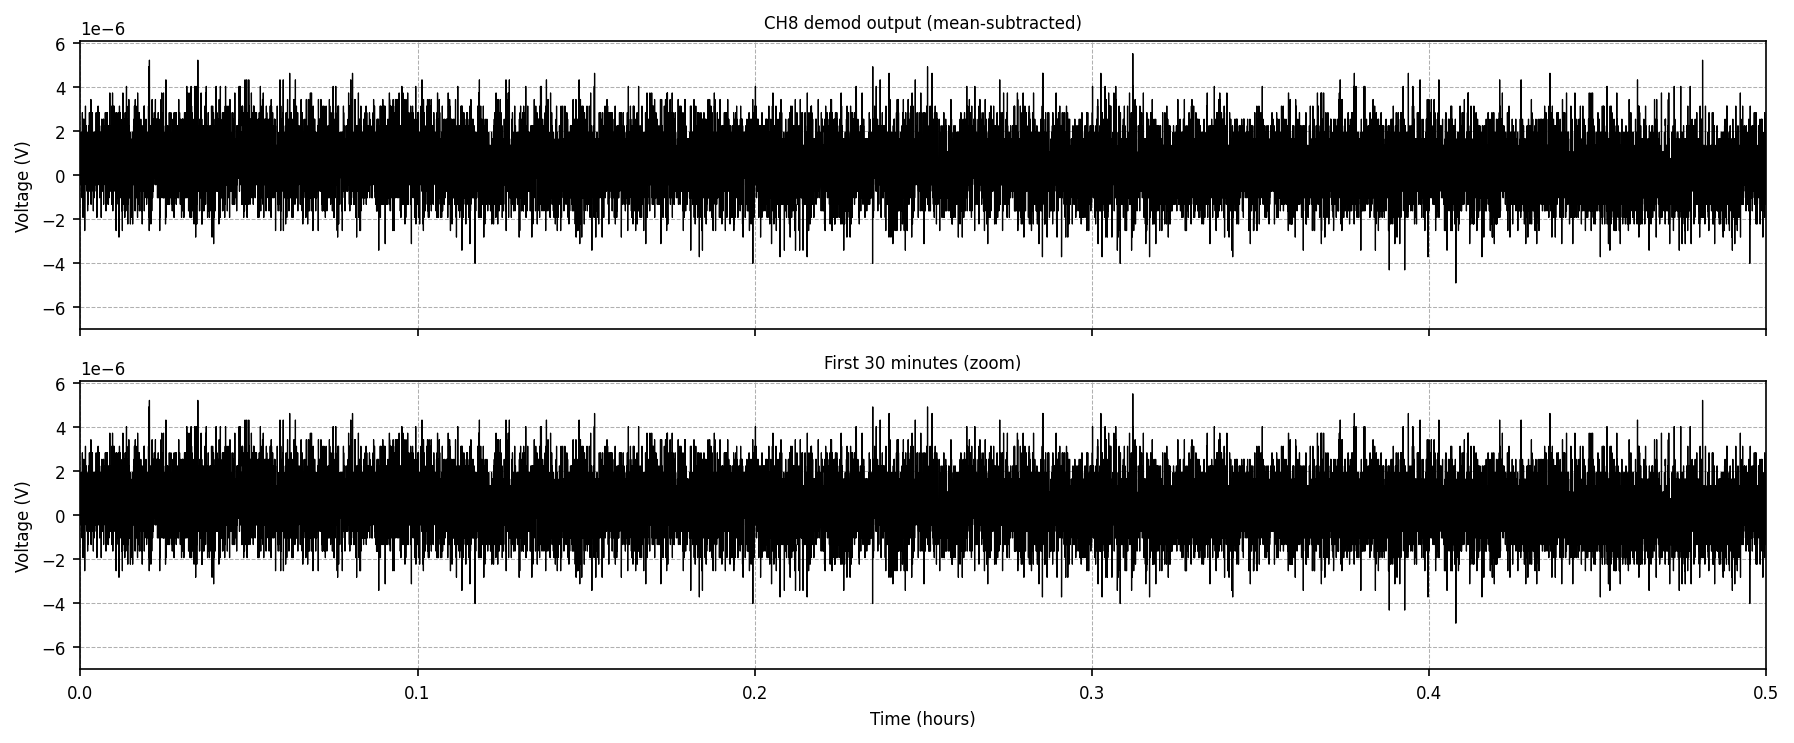

In [4]:
t = np.arange(len(volts)) / fs

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t / 3600, volts, linewidth=0.6)
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title("CH8 demod output (mean-subtracted)")
axes[0].grid(True, linestyle="--", linewidth=0.5)

axes[1].plot(t / 3600, volts, linewidth=0.6)
axes[1].set_xlim(0, min(0.5, duration_s / 3600))
axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("Voltage (V)")
axes[1].set_title("First 30 minutes (zoom)")
axes[1].grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

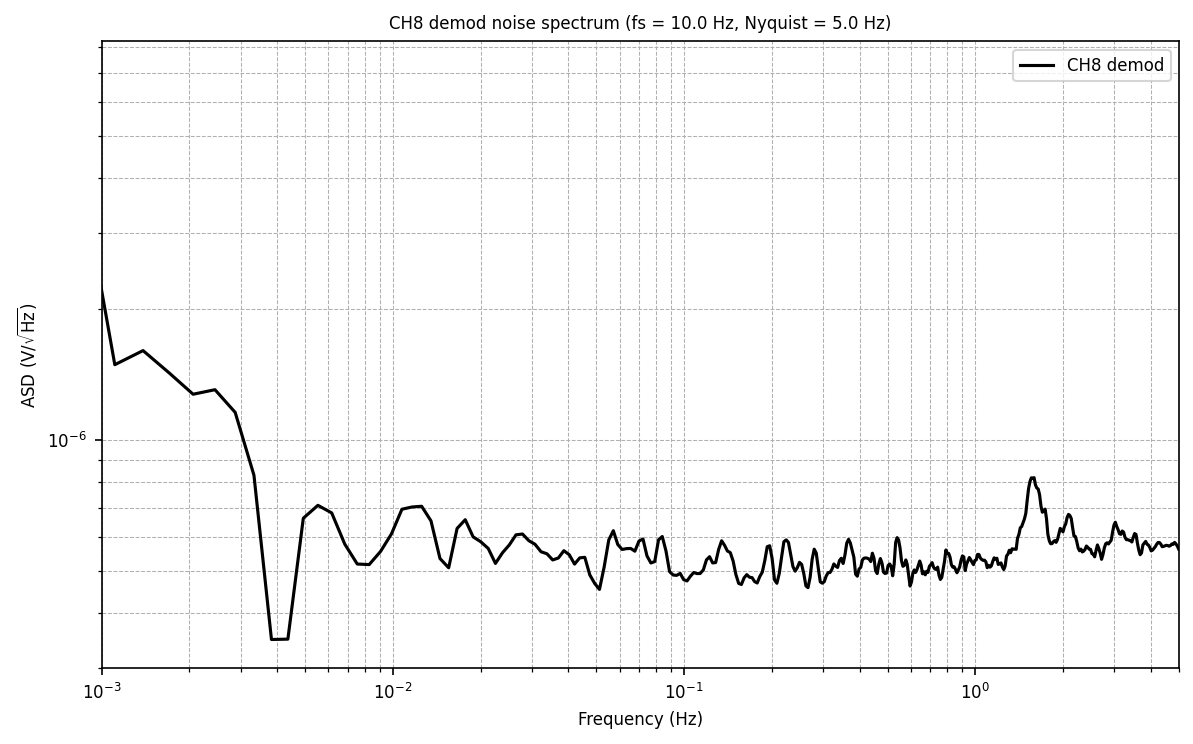

In [5]:
speckit_kw = dict(Jdes=900, Kdes=100, order=0, win="Kaiser", psll=200, verbose=False)
result = compute_spectrum(volts, fs=fs, **speckit_kw)

nyquist = fs / 2.0
fig, ax = plt.subplots(figsize=(8, 5))
result.plot(which="asd", ax=ax, label="CH8 demod")
ax.set_xlim(0.001, nyquist)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel(r"ASD (V/$\sqrt{\rm Hz}$)")
ax.set_title(f"CH8 demod noise spectrum (fs = {fs:.1f} Hz, Nyquist = {nyquist:.1f} Hz)")
ax.legend()
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

In [6]:
bin_freqs_hz = [0.01, 0.05, 0.1, 0.5, 1.0]
rows = []
for freq in bin_freqs_hz:
    if freq >= nyquist:
        continue
    bin_result = compute_single_bin(
        volts,
        fs,
        freq=freq,
        fres=0.01,
        win="Kaiser",
        psll=200,
    )
    rows.append({"freq_hz": freq, "asd_v_per_sqrt_hz": float(bin_result.asd[0])})

asd_table = pd.DataFrame(rows)
display(asd_table)

print(f"Time-domain RMS: {volts.std():.6e} V")

,freq_hz,asd_v_per_sqrt_hz
0,0.01,5.142317e-07
1,0.05,5.371746e-07
2,0.10,5.106774e-07
3,0.50,5.040569e-07
4,1.00,5.297774e-07


Time-domain RMS: 1.393216e-06 V
